## tl;dr
An explicitly synthetic empirical wind-tunnel simulator is available. It preserves integer SOC and stochastic step timing. It is not a validated replacement for missing experiments.


## Context & Methods
### Key Assumptions
Per-battery baseline rates are offsets. Conditional log-dwell prediction uses SOC, own stage, startup progress and condition. Holdout groups keep conditions, flights and drones together. Randomness uses development out-of-fold residual blocks. Unmodelled coordinates, attitude and temperature are blank. The generator was revised after internal synthetic QA; held-out stochastic distribution checks are descriptive.


In [1]:
from pathlib import Path
import sys,json
import pandas as pd
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'battery_normalization.py').exists())
sys.path.insert(0,str(ROOT/'output_py'))
from wind_tunnel_simulation_model import OUTPUT,sha
from generate_wind_tunnel_simulation import DEST
from package_wind_tunnel_simulation import curve_data,plot_notebook_figures,SQL


## Data
Observed source files and frozen baseline hashes are in input_manifest.json; generated files are listed in run_manifest.csv. The simulator never imports an aircraft SDK.


In [2]:
m=json.loads((OUTPUT/'input_manifest.json').read_text())
for path,expected in m['input_sha256'].items():
    assert sha(ROOT/path)==expected
print('Source hashes unchanged:',len(m['input_sha256']))
print(pd.read_csv(DEST/'coverage.csv').groupby('coverage').size().to_string())


Source hashes unchanged: 165
coverage
locally_supported_all_15_cells     7
missing_usable_curves             36
partial                           17


## Results
Deterministic prediction is evaluated on untouched held-out conditions. Metrics sum predicted and observed duration for the SAME eligible SOC steps, not nominal whole stages.


In [3]:
import sqlite3
d=pd.read_csv(OUTPUT/'holdout_predictions.csv')
con=sqlite3.connect(':memory:')
d.to_sql('holdout_predictions',con,index=False)
r=pd.read_sql_query(SQL,con)
print('Curve-stage mean absolute percentage time error:',r.absolute_error_pct.mean())
print(pd.read_csv(OUTPUT/'matched_distribution_metrics.csv').to_string(index=False))


Curve-stage mean absolute percentage time error: 21.070678975648562
 stage  observed_steps  simulation_draws  observed_median_s  simulated_median_s  observed_p10_s  simulated_p10_s  observed_p90_s  simulated_p90_s  wasserstein_s  ks_distance
  high             249              4980              2.126            2.683128          1.9234         1.809200          7.9082         6.129263       0.609653     0.215060
medium             781             15620              6.920            6.507634          3.9200         3.634837          9.8610        10.711983       0.637021     0.095391
   low             863             17260              4.041            4.176915          2.0602         2.418838          7.0116         7.219691       0.252163     0.118308


Generated notebook_curve_comparison.png and notebook_dwell_comparison.png


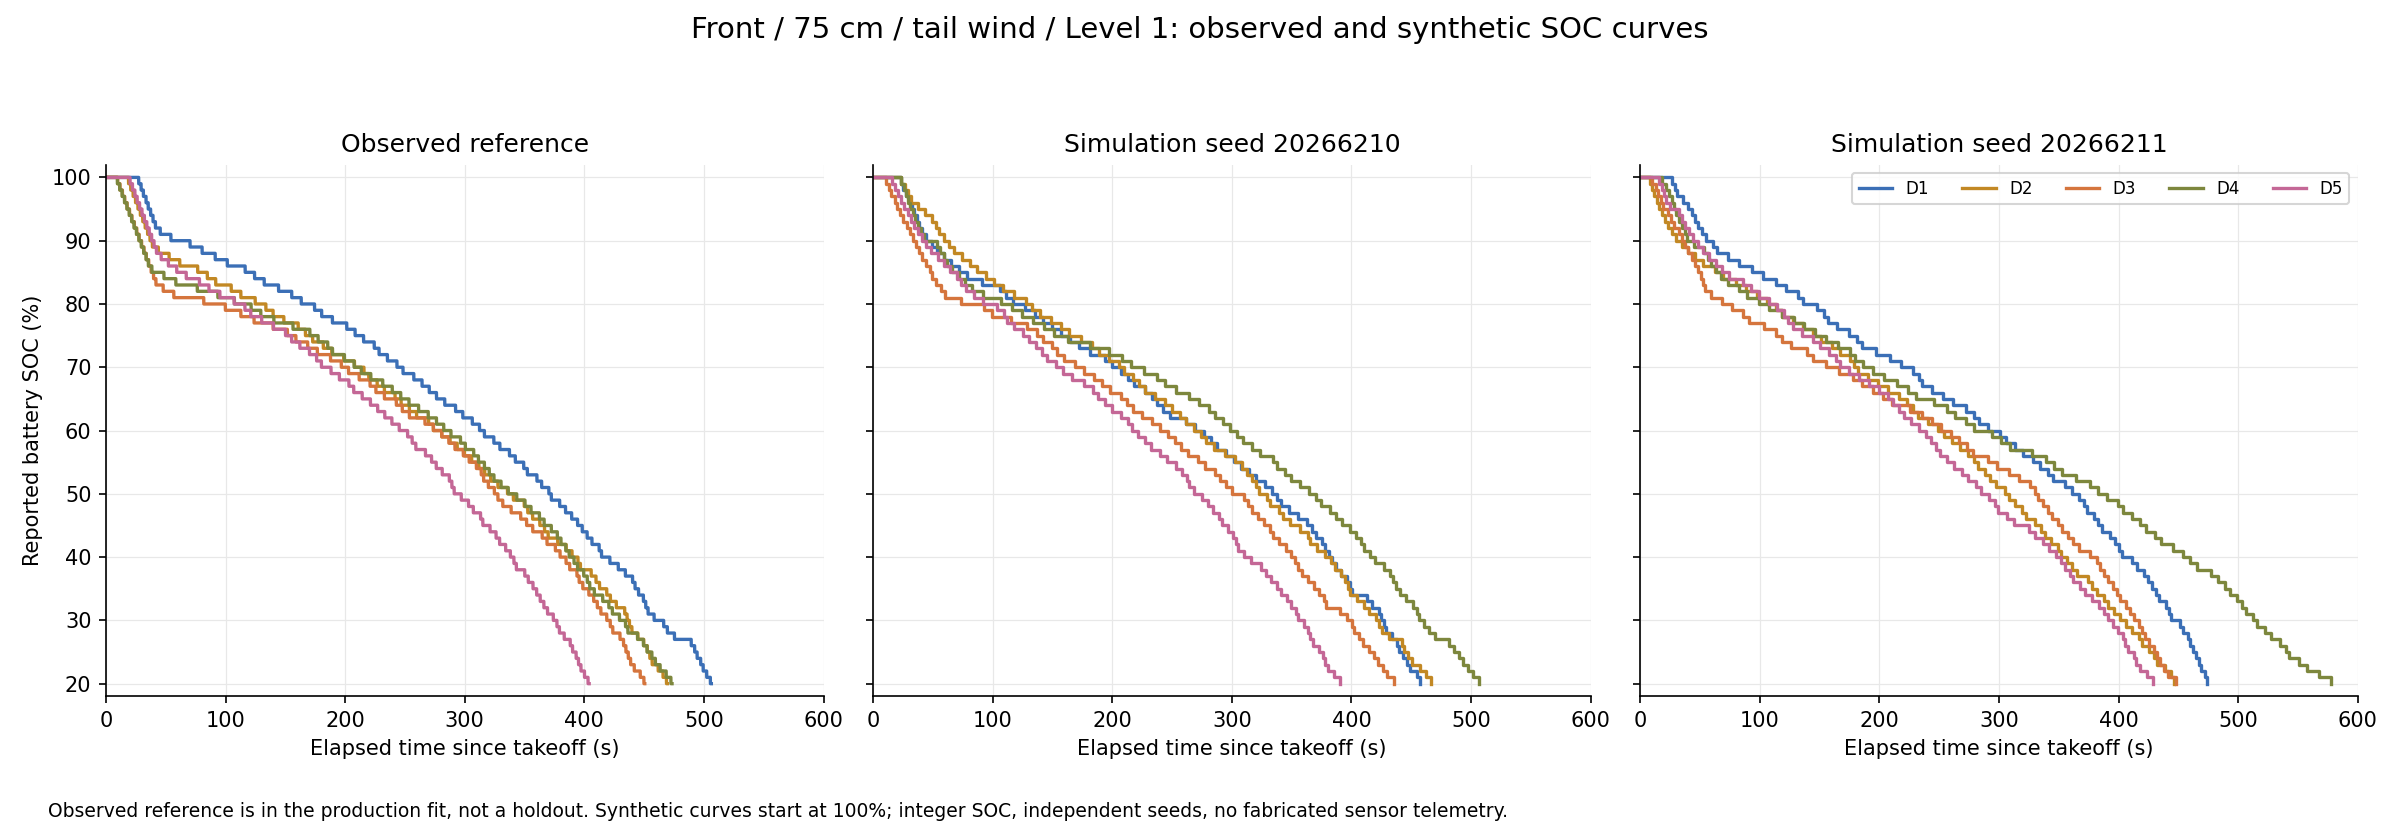

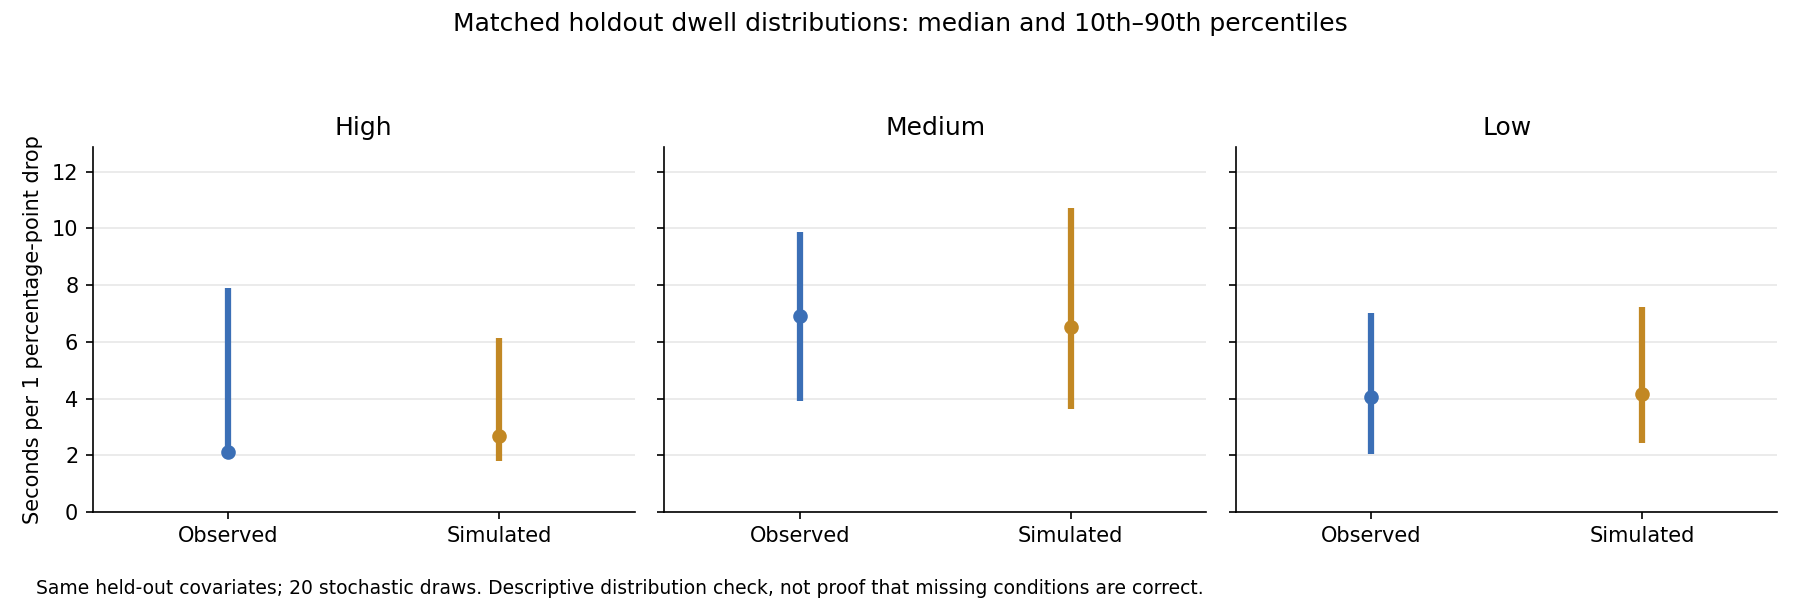

In [4]:
plot_notebook_figures(curve_data())
print('Generated notebook_curve_comparison.png and notebook_dwell_comparison.png')


## Takeaways
Use these simulations for algorithm exploration and sensitivity analysis, not as measured replications or independent experimental validation. High/Medium transfer errors remain material; battery, drone and position are confounded. No causal leader or spacing rule was hardcoded. No 2.5 m forward-flight rates were transplanted to hover.
